<a href="https://colab.research.google.com/github/rypriyanka2005/Machine-Learning-Sem-4/blob/MLlabs/MLLab4full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training Confusion Matrix:
 [[  4   0   0   0   0   0   0   0   2   0]
 [  0  10   0   0   0   0   0   1   2   0]
 [  0   0  34   1   0   0   1   0   5   1]
 [  0   1   2  17   0   0   0   0   6   0]
 [  0   0   2   0  13   0   0   1   3   0]
 [  0   0   6   0   0   7   0   0   2   0]
 [  1   1  11   3   0   3  32   0   8   3]
 [  0   1   5   0   2   0   4  15   8   0]
 [  1   2  16   1   0   6   7   3 127   3]
 [  0   1  10   2   1   6   4   1   5  29]]
Training -> Precision: 0.6923380393936591 Recall: 0.6501128668171557 F1: 0.6542466805727556

Test Confusion Matrix:
 [[ 0  1  0  0  0  0  1  0  0  0]
 [ 0  0  3  0  0  0  1  1  0  0]
 [ 1  1 12  1  0  2  1  2  7  1]
 [ 0  0  2  0  0  0  1  0  3  0]
 [ 0  1  1  0  2  0  0  1  4  0]
 [ 0  0  2  1  0  0  0  0  0  0]
 [ 0  0  7  3  0  3  7  3 15  2]
 [ 1  0  0  0  0  1  4  5 14  0]
 [ 1  1  6  3  1  1  3  1 25  2]
 [ 0  0  4  0  1  3  4  1 11  4]]
Test -> Precision: 0.3242390542856899 Recall: 0.2894736842105263 F1: 0.2762654720963554

Mode

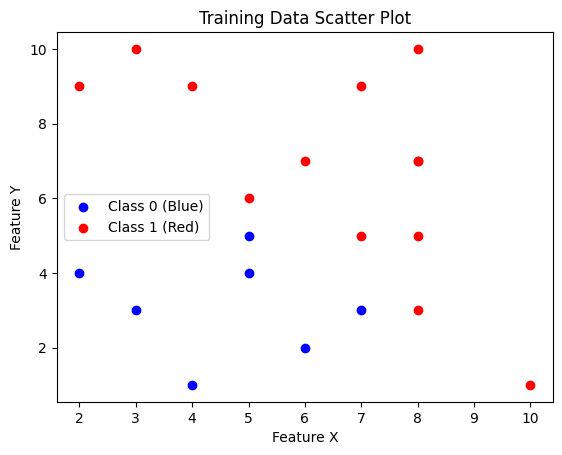

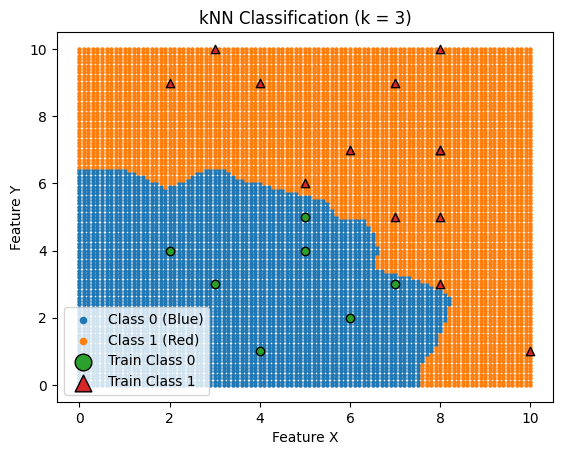

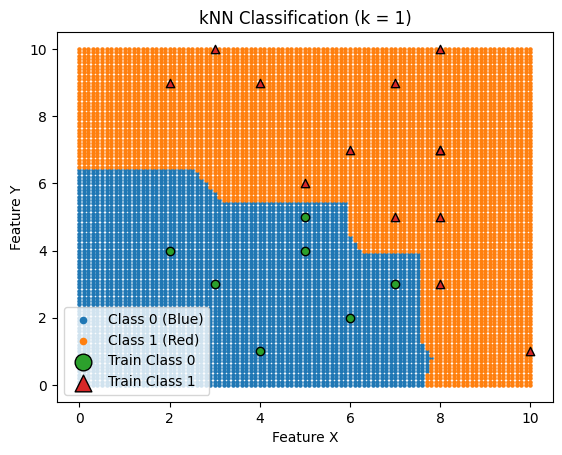

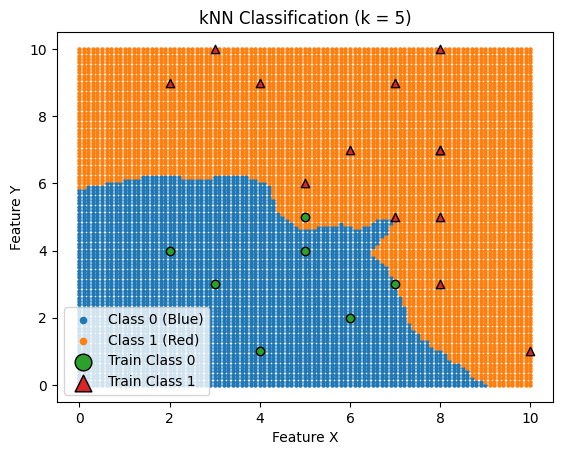

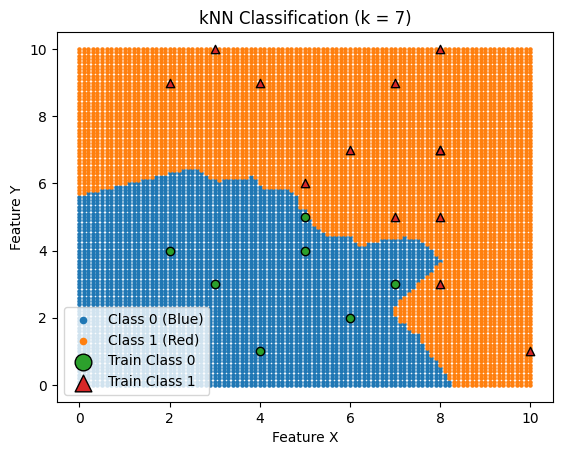

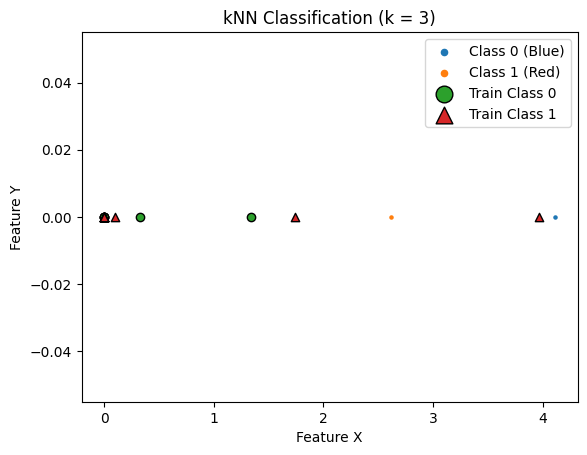

Best k value: 13
Best Cross-Validation Accuracy: 0.41085291113381006
Best k value: 13
Best Cross-Validation Accuracy: 0.41085291113381006


In [13]:
from scipy.spatial.distance import minkowski
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score




features = np.load("/content/features.npy")
label_names = np.load("/content/label_names.npy")
labels = np.load("/content/labels.npy")

#A1
X = features
y = labels
# separates the training and the testing part in the ratio of 7:3
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#trains with the dataset got from the split with k=3
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

#confusion matrix precision recall f1score for the test dataset
def performance_metrics(model, X, y):
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred)
    precision = precision_score(y, y_pred, average='weighted')
    recall = recall_score(y, y_pred, average='weighted')
    f1 = f1_score(y, y_pred, average='weighted')
    return cm, precision, recall, f1

cm_train, p_train, r_train, f1_train = performance_metrics(model, X_train, y_train)
cm_test, p_test, r_test, f1_test = performance_metrics(model, X_test, y_test)

# infering output
def infer_learning_outcome(f1_train, f1_test):
    if f1_train > 0.9 and f1_test < 0.7:
        return "Overfitting"
    elif f1_train < 0.7 and f1_test < 0.7:
        return "Underfitting"
    else:
        return "Regular fitting (Good Generalization)"

print("Training Confusion Matrix:\n", cm_train)
print("Training -> Precision:", p_train, "Recall:", r_train, "F1:", f1_train)

print("\nTest Confusion Matrix:\n", cm_test)
print("Test -> Precision:", p_test, "Recall:", r_test, "F1:", f1_test)
outcome = infer_learning_outcome(f1_train, f1_test)
print("\nModel Learning Outcome:", outcome)


#A2

df = pd.read_excel('/content/Lab Session Data.xlsx', sheet_name=0)

X = df[['Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)']]
y = df['Payment (Rs)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

#Train Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

#Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

#  Metrics Function
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mape, r2

#  Training Metrics
mse_train, rmse_train, mape_train, r2_train = regression_metrics(
    y_train, y_train_pred
)

#Testing Metrics
mse_test, rmse_test, mape_test, r2_test = regression_metrics(
    y_test, y_test_pred
)


print("TRAINING METRICS")
print("MSE  :", mse_train)
print("RMSE :", rmse_train)
print("MAPE :", mape_train)
print("R2   :", r2_train)

print("\nTESTING METRICS")
print("MSE  :", mse_test)
print("RMSE :", rmse_test)
print("MAPE :", mape_test)
print("R2   :", r2_test)

#A3
# fixing random values
np.random.seed(42)

# Generate 20 data points (values between 1 and 10)
X = np.random.randint(1, 11, size=20)
Y = np.random.randint(1, 11, size=20)

# Assign classes
# Class 0 (Blue): X + Y <= 10
# Class 1 (Red):  X + Y > 10
labels = np.where(X + Y > 10, 1, 0)

# Scatter plot
plt.figure()
plt.scatter(X[labels == 0], Y[labels == 0], color='blue', label='Class 0 (Blue)')
plt.scatter(X[labels == 1], Y[labels == 1], color='red', label='Class 1 (Red)')
plt.xlabel('Feature X')
plt.ylabel('Feature Y')
plt.title('Training Data Scatter Plot')
plt.legend()
plt.show()


#A4
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# Data Functions
def generate_training_data(n=20):
    np.random.seed(42)
    x1 = np.random.randint(1, 11, n)
    x2 = np.random.randint(1, 11, n)
    y = np.where(x1 + x2 > 10, 1, 0)
    return np.column_stack((x1, x2)), y

def generate_test_data():
    x = np.arange(0, 10.1, 0.1)
    y = np.arange(0, 10.1, 0.1)
    xx, yy = np.meshgrid(x, y)
    return np.c_[xx.ravel(), yy.ravel()]

# kNN Function
def knn_predict(X_train, y_train, X_test, k):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    return model.predict(X_test)

# Plot Function
def plot_knn(X_train, y_train, X_test, y_pred, k):
    plt.figure()
    plt.scatter(X_test[y_pred == 0, 0], X_test[y_pred == 0, 1], s=5, label='Class 0 (Blue)')
    plt.scatter(X_test[y_pred == 1, 0], X_test[y_pred == 1, 1], s=5, label='Class 1 (Red)')
    plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
                edgecolors='black', marker='o', label='Train Class 0')
    plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
                edgecolors='black', marker='^', label='Train Class 1')
    plt.xlabel("Feature X")
    plt.ylabel("Feature Y")
    plt.title(f"kNN Classification (k = {k})")
    plt.legend(markerscale=2)
    plt.show()


X_train, y_train = generate_training_data()
X_test = generate_test_data()

# A4: k = 3
y_pred = knn_predict(X_train, y_train, X_test, k=3)
plot_knn(X_train, y_train, X_test, y_pred, k=3)



#A5
#Repeat for different k values
for k in [1, 5, 7]:
    y_pred = knn_predict(X_train, y_train, X_test, k)
    plot_knn(X_train, y_train, X_test, y_pred, k)

#A5
#A3 TO A5 for our project data
X = features
labels = np.load("/content/labels.npy") # Reload the original labels
y = labels
# separates the training and the testing part in the ratio of 7:3
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#trains with the dataset got from the split with k=3
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)
#class boundry for our project
y_pred1 = model.predict(X_test)
plot_knn(X_train, y_train, X_test, y_pred1, 3)


#A7

import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Train-test split (7:3)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# kNN model
knn = KNeighborsClassifier()

# Hyperparameter grid
param_grid = {
    'n_neighbors': list(range(1, 21))
}

# Grid Search
grid_search = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

# Best results
best_k = grid_search.best_params_['n_neighbors']
best_score = grid_search.best_score_

print("Best k value:", best_k)
print("Best Cross-Validation Accuracy:", best_score)


from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_neighbors': np.arange(1, 51)
}

random_search = RandomizedSearchCV(
    knn,
    param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best k value:", random_search.best_params_['n_neighbors'])
print("Best Cross-Validation Accuracy:", random_search.best_score_)
